# Illustrate the iEGM through a unitary model

## Monte Carlo Settings

In [1]:
MC_num = 50 #200 # number of Monte Carlo simulations
C_num_grid = (25,50,75,100,200) # number of grid points in consumption grid i iEGM
do_print = True # whether to print results during Monte Carlo iterations

common_specs = { # common specifications across methods
    'num_m':100,    # number of points in the single state: normalized resources
    'max_m':5.0,    # maximum level of normalized resources

    'max_C':10.0,   # maximum level of consumption in iEGM precomputation

    'T': 20,        # number of periods
    'simN':10_000,  # number of agents in simulation

} 

## Load relevant packages

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from UnitaryModel import UnitaryModelClass

plt.rcParams.update({'font.size': 14})

## Illustrate the pre-computation of consumption interpolator

In [3]:
# load local model file and initialize model class
SAVE = True
specs_illustrate = {
    'rho_w':1.5,
    
    'restricted_model':False,

    'num_C':10,
    'max_C':5.0,
    'unequal_C':1.5,
    
    'precompute_intra':True,
}

model = UnitaryModelClass(par=specs_illustrate)
par = model.par

# pre-compute consumption
model.precompute_C()

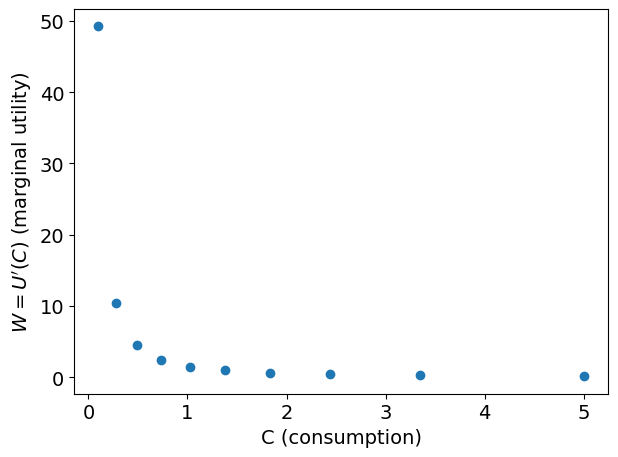

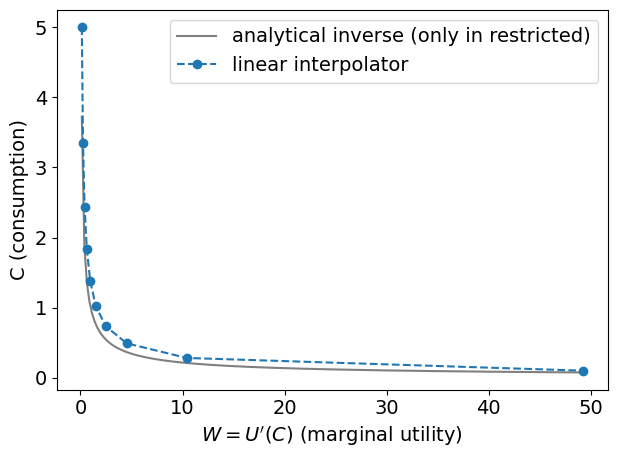

In [4]:
# illustrate the iEGM pre-computation
fig, ax = plt.subplots()
ax.scatter(par.grid_C,par.grid_marg_U)
ax.set(xlabel='C (consumption)',ylabel="$W=U\'(C)$ (marginal utility)");
fig.tight_layout()

fig, ax = plt.subplots()
fine_grid = np.linspace(par.grid_marg_U_flip[0],par.grid_marg_U_flip[-1],200)
ax.plot(fine_grid,model.inv_marg_HH_util(fine_grid),color='gray',label='analytical inverse (only in restricted)')
ax.plot(par.grid_marg_U_flip,par.grid_C_flip,marker='o',linestyle='--',color='tab:blue',label='linear interpolator');
ax.set(xlabel='$W=U\'(C)$ (marginal utility)',ylabel="C (consumption)");
ax.legend();
fig.tight_layout()

## Solve the "true" model using many grid points in VFI

In [5]:
specs_true = {
    'method':'vfi',
    
    'num_m':1000,
    'max_m':20.0,
}

model_true_restricted = UnitaryModelClass(par={**specs_true,'restricted_model':True})
%time model_true_restricted.solve()
%time model_true_restricted.simulate()

CPU times: total: 23.5 s
Wall time: 23.5 s
CPU times: total: 31.2 ms
Wall time: 38.3 ms


## Accuracy measures

In [6]:
grid_m_MSE = np.linspace(0.5,5.0,100) # points to evaluatre the consumption function

# interpolator of household utility. This is to simulate lifetime utility without having to resolve the model many times
C_grid = np.linspace(model_true_restricted.par.grid_C[0],model_true_restricted.par.grid_C[-1],300)


HH_util_grid_restr = np.nan + np.ones(len(C_grid))
for i,C in enumerate(C_grid):
    HH_util_grid_restr[i] = model_true_restricted.HH_util(C,recalculate=True)
HH_util_restr = {'C_grid':C_grid,'HH_util_grid':HH_util_grid_restr}

model_true_restricted.lifetime_utility(HH_util_restr)

In [7]:
common_specs = {
    'num_m': 40,
    'num_C':30,
}



In [8]:
model_specs = {    
    'vfi': {'method':'vfi','table_name':'VFI'},
    
    'egm': {'method':'egm','table_name':'EGM'},
    'iegm (num)': {'method':'iegm','interp_method':'numerical','precompute_intra':False,'table_name':'EGM (num)'}, # note that if we do not precopute the Marg_HH_util, this is super slow
    'iegm': {'method':'iegm','interp_method':'linear','precompute_intra':True,'table_name':'iEGM'},
}

# model_specs_pre = {    
#     'vfi, pre': {'method':'vfi','precompute_E':True,'table_name':'VFI, pre E'},
#     'iegm (num), pre': {'method':'iegm','interp_method':'numerical','precompute_E':True,'precompute_intra':False,'table_name':'EGM (num), pre E'}, # note that if we do not precopute the Marg_HH_util, this is super slow
#     'vfi (simul), pre': {'method':'vfi_simul','precompute_E':True,'table_name':'VFI (simul.), pre E'},
    
#     'vfi, pre all': {'method':'vfi','precompute_E':True,'precompute_intra':True,'table_name':'VFI, pre E + intra'},
#     'iegm (num), pre all': {'method':'iegm','interp_method':'numerical','precompute_E':True,'precompute_intra':True,'table_name':'EGM (num), pre E + intra'}, # note that if we do not precopute the Marg_HH_util, this is super slow
    
#     # 'iegm, pre': {'method':'iegm','interp_method':'linear','precompute_E':True,'precompute_intra':True,'table_name':'iEGM, pre E (+ intra)'},
# }

In [10]:
models = {}
results = {}
for restricted in [True,]:
    for name_base,specs in {**model_specs,}.items():
        
        
        if ('iegm' in name_base) and (specs['interp_method']!='numerical'):
            C_num_grid_now = C_num_grid
        else:
            C_num_grid_now = (20,) # not used
        
        for num_C in C_num_grid_now:  
            restricted_str = 'restricted' if restricted else 'unrestricted'
            name = name_base + (f' num_C={num_C}' if len(C_num_grid_now)>1 else '')
            key = (restricted_str,num_C) if len(C_num_grid_now)>1 else restricted_str
            
            if name not in results:
                results[name] = {}
            results[name][key] = {
                'timing':np.nan+np.ones(MC_num),
                'timing_rel':np.nan+np.ones(MC_num),
                'MSE':np.nan+np.ones(MC_num),
                'MAD':np.nan+np.ones(MC_num),
                'util_diff_pct':np.nan+np.ones(MC_num),
                'comp':np.nan+np.ones(MC_num),
            } 
            
            if (not restricted) & (('egm' == name_base) | ('egm, pre' == name_base)):
                continue # skip unrestricted EGM since it is not available for this model
            if (restricted) & ('vfi (simul)' in name_base):
                continue # skip restricted VFI simul since closed form used here
            
            if do_print: print(name,key)
            model_name = name + '_restricted' if restricted else name
            # setup model and solution containers
            models[model_name] = UnitaryModelClass(par={**common_specs,**specs,'num_C':num_C,'restricted_model':restricted})
            
            # loop over Monte Carlo iterations
            for i_mc in range(MC_num):
                if do_print: print(f'{i_mc+1}/{MC_num} running...')
                
                # re-simulate true model for this Monte Carlo iteration to get new draws
                if 'restricted' in name_base:
                    print(restricted,restricted_str)
                # true = model_true_restricted if 'restricted' in name_base else model_true
                # util = HH_util_restr if 'restricted' in name_base else HH_util
                true = model_true_restricted 
                util = HH_util_restr 
                
                true.par.seed = i_mc
                true.allocate_draws()
                true.simulate()
                true.lifetime_utility(util) 
                
                # solution time
                t0 = time()
                models[model_name].solve()
                secs = time() - t0
                if do_print: print(f'Solution time: {secs:.2f} seconds')
                
                # accuracy
                MSE,MAD = models[model_name].MSE_consumption(true,grid_m_MSE)
                if do_print: print(f'MSE in consumption function: {MSE:.4f}')
                if do_print: print(f'MAD in consumption function: {MAD:.4f}')
                
                models[model_name].par.seed = i_mc
                models[model_name].allocate_draws()
                models[model_name].simulate()
                
                diff_pct = models[model_name].lifetime_utility(util,true)
                if do_print: print(f'Difference in lifetime utility (compared to true model): {diff_pct:.4f}')
                
                comp = models[model_name].wealth_compensation(util,true)
                if do_print: print(f'Wealth compensation (pct of household exp. income): {comp:.4f}',end='\n\n')
                
                results[name][key]['timing'][i_mc] = secs
                results[name][key]['timing_rel'][i_mc] = secs/results['vfi'][restricted_str]['timing'][i_mc]
                results[name][key]['MSE'][i_mc] = MSE
                results[name][key]['MAD'][i_mc] = MAD
                results[name][key]['util_diff_pct'][i_mc] = diff_pct
                results[name][key]['comp'][i_mc] = comp

vfi restricted
1/50 running...
Solution time: 1.02 seconds
MSE in consumption function: 0.0001
MAD in consumption function: 0.0056
Difference in lifetime utility (compared to true model): 0.0021
Wealth compensation (pct of household exp. income): 0.0000

2/50 running...
Solution time: 1.02 seconds
MSE in consumption function: 0.0001
MAD in consumption function: 0.0056
Difference in lifetime utility (compared to true model): 0.0021
Wealth compensation (pct of household exp. income): 0.0000

3/50 running...
Solution time: 1.01 seconds
MSE in consumption function: 0.0001
MAD in consumption function: 0.0056
Difference in lifetime utility (compared to true model): 0.0020
Wealth compensation (pct of household exp. income): 0.0000

4/50 running...
Solution time: 1.01 seconds
MSE in consumption function: 0.0001
MAD in consumption function: 0.0056
Difference in lifetime utility (compared to true model): 0.0023
Wealth compensation (pct of household exp. income): 0.0000

5/50 running...
Solution 

KeyboardInterrupt: 

In [ ]:
# write to latex file
do_both_pre = False # whether to include the restricted model in the pre-computed verions
table_path = 'output/MC_unitary_TEST'
output = ('timing','timing_rel','MAD','comp')
output_labels = '& time (s) & rel. & MAD(C)  & Comp(A) '

num_cols_per_model = len(output)

for pre in (False,True):
    pre_str = ', pre' if pre else ''
    tab_name = table_path + '_pre' if pre else table_path
    
    num_models = 1 if pre & (not do_both_pre) else 2
    num_cols = 2 + num_cols_per_model*num_models
    
    with open(tab_name+'.tex','w') as f:
        # table head
        f.write('\\begin{tabular}{ll' + 'c'* (num_cols-2) + '} \\toprule\n')
        if num_models==2:
            f.write(f'&& \\multicolumn{{{num_cols_per_model}}}{{c}}{{Restricted model}} & \\multicolumn{{{num_cols_per_model}}}{{c}}{{Unrestricted model}} \\\\ \n ')
            f.write(f'\\cmidrule(lr){{3-{2+num_cols_per_model}}} \\cmidrule(lr){{{3+num_cols_per_model}-{num_cols}}} &')
        else:
            f.write(f'&& \\multicolumn{{{num_cols_per_model}}}{{c}}{{Unrestricted model}}  \\\\ \n ')
            f.write(f'\\cmidrule(lr){{3-{2+num_cols_per_model}}} &')
        for _ in range(num_models): f.write(output_labels)
        f.write('\\\\ \\midrule \n')
        
        # table body
        model_specs_now = model_specs_pre if pre else model_specs
        for name_base,specs in model_specs_now.items():
            table_name = specs['table_name']
            
            if ('iegm' in name_base) and (specs['interp_method']!='numerical'):
                C_num_grid_now = C_num_grid
            else:
                C_num_grid_now = (20,) # not used
            
            #num_multi = 1 if len(C_num_grid_now)>1 else 2
            f.write(f'\\multicolumn{{{2}}}{{l}}{{{table_name}}} ')
            for iC,num_C in enumerate(C_num_grid_now):  
                if len(C_num_grid_now)>1:
                    if iC==0: # skip entire row
                        f.write(f'\\multicolumn{{{num_cols-2}}}{{c}}{{}} \\\\ \n')
                    
                    f.write(f'& $\\#_C$={num_C}')
                
                for restricted in [True,False]:
                    if (num_models==1) and restricted:
                        continue
                    name = name_base + (f' num_C={num_C}' if len(C_num_grid_now)>1 else '')
                    restricted_str = 'restricted' if restricted else 'unrestricted'
                    key = (restricted_str,num_C) if len(C_num_grid_now)>1 else restricted_str
                    
                    for out in output:
                        avg = np.mean(results[name][key][out])
                        if np.isnan(avg):
                            f.write('& N.A. ')
                        else:
                            f.write(f'& {avg:.3f} ')
                f.write('\\\\ \n')
        f.write('\\bottomrule \\end{tabular}\n')
        
        
    # output the table here by looping through all lines in the file and printing them
    with open(tab_name+'.tex','r') as f:
        for line in f:
            print(line,end='')  



\begin{tabular}{llcccccccc} \toprule
&& \multicolumn{4}{c}{Restricted model} & \multicolumn{4}{c}{Unrestricted model} \\ 
 \cmidrule(lr){3-6} \cmidrule(lr){7-10} && time (s) & rel. & MAD(C)  & Comp(A) & time (s) & rel. & MAD(C)  & Comp(A) \\ \midrule 
\multicolumn{2}{l}{VFI} & 0.790 & 1.000 & 0.014 & 0.000 & 12.636 & 1.000 & 0.005 & 0.000 \\ 
\multicolumn{2}{l}{EGM} & 0.043 & 0.055 & 0.013 & 0.000 & N.A. & N.A. & N.A. & N.A. \\ 
\multicolumn{2}{l}{EGM (num)} & 0.072 & 0.092 & 0.013 & 0.000 & 125.027 & 9.974 & 0.002 & 0.000 \\ 
\multicolumn{2}{l}{iEGM} \multicolumn{8}{c}{} \\ 
& $\#_C$=25& 0.044 & 0.055 & 0.217 & 14.652 & 0.139 & 0.011 & 0.014 & 0.000 \\ 
& $\#_C$=50& 0.044 & 0.056 & 0.063 & 0.840 & 0.229 & 0.018 & 0.004 & 0.000 \\ 
& $\#_C$=75& 0.043 & 0.055 & 0.038 & 0.000 & 0.341 & 0.027 & 0.003 & 0.000 \\ 
& $\#_C$=100& 0.040 & 0.050 & 0.027 & 0.000 & 0.436 & 0.035 & 0.003 & 0.000 \\ 
& $\#_C$=200& 0.047 & 0.060 & 0.015 & 0.000 & 0.826 & 0.066 & 0.002 & 0.000 \\ 
\bottomrule \end{ta

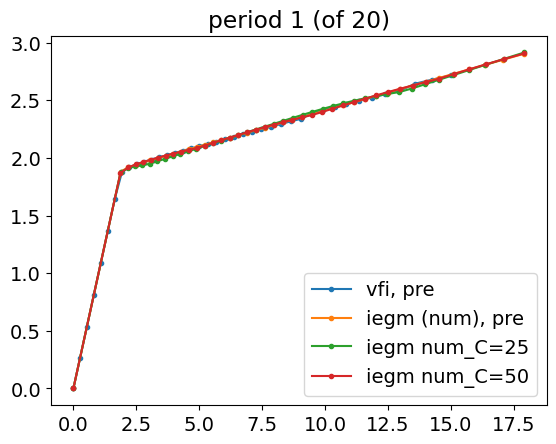

In [ ]:
plot_names = ('vfi, pre','iegm (num), pre','iegm num_C=25','iegm num_C=50')
for t in (-20,):
    fig,ax = plt.subplots()
    for name in plot_names:
        m_interp = np.concatenate((np.array([0.0]),models[name].sol.M[t]))
        c_interp = np.concatenate((np.array([0.0]),models[name].sol.C[t]))
        ax.plot(m_interp,c_interp,label=name,marker='.')
        ax.legend();
        ax.set(title=f'period {models[name].par.T+t+1} (of {models[name].par.T})');